In [2]:
from google import genai
from google.genai import types
from dotenv import load_dotenv
import os

In [4]:
google_api_key = os.getenv("GOOGLE_API_KEY")


In [5]:
from decomposition.success_detector import *

In [7]:
client = get_client(google_api_key)
print(type(client))
#print(hello_world(client))

<class 'google.genai.client.Client'>


In [9]:
'true' in 'it is true...'

True

In [8]:
hello_world(client)

TypeError: 'str' object is not callable

In [12]:
from collections import defaultdict
import numpy as np

In [8]:
a = defaultdict(lambda : [0,0])
a['a'][0] += 1 
print(a['a'])

[1, 0]


In [11]:
def update_dict(my_dict, line):

    task, result, _ = line.rsplit("_", 2)
    #print(task)
    #print(result)
    my_dict[task][1] += 1
    if result == 'success':
        my_dict[task][0] += 1
results_dict = defaultdict(lambda: [0,0])
with open('libero_10_20_trials_seed_7_video_names.txt', 'r') as f:
    for l in f:
        update_dict(results_dict, l)
rate_dict = {k : v[0] / v[1] for k, v in results_dict.items()}
for k, v in rate_dict.items():
    print(f"{k}: {v}")



rollout_pick_up_the_book_and_place_it_in_the_back_compartment_of_the_caddy: 0.75
rollout_put_both_moka_pots_on_the_stove: 0.0
rollout_put_both_the_alphabet_soup_and_the_cream_cheese_box_in_the_basket: 1.0
rollout_put_both_the_alphabet_soup_and_the_tomato_sauce_in_the_basket: 0.85
rollout_put_both_the_cream_cheese_box_and_the_butter_in_the_basket: 1.0
rollout_put_the_black_bowl_in_the_bottom_drawer_of_the_cabinet_and_close_it: 0.5
rollout_put_the_white_mug_on_the_left_plate_and_put_the_yellow_and_white_mug_on_the_right_plate: 0.9
rollout_put_the_white_mug_on_the_plate_and_put_the_chocolate_pudding_to_the_right_of_the_plate: 0.85
rollout_put_the_yellow_and_white_mug_in_the_microwave_and_close_it: 0.3
rollout_turn_on_the_stove_and_put_the_moka_pot_on_it: 0.3


In [52]:
#data = np.load('data/libero/videos/libero_1/ep_1742315958_5983229/state_1742315995_2950754.npz', allow_pickle=True)



data = np.load('/home/christopher/Documents/openpi/data/libero/videos/libero_1/ep_1742322655_868923/state_1742322690_7243073.npz', allow_pickle=True)

In [53]:
list(data.keys())

['states', 'action_infos', 'successful', 'env']

In [54]:
print(data['states'].shape)
print(len(data['action_infos']))


(262, 51)
261


In [55]:
data['action_infos'][0]

{'actions': array([ 0.,  0.,  0.,  0.,  0.,  0., -1.]),
 'agentview_image': array([[[200, 182, 162],
         [199, 181, 161],
         [199, 181, 161],
         ...,
         [197, 180, 164],
         [194, 177, 161],
         [198, 181, 165]],
 
        [[200, 183, 163],
         [200, 182, 162],
         [199, 181, 161],
         ...,
         [196, 179, 163],
         [195, 178, 162],
         [201, 184, 168]],
 
        [[199, 182, 162],
         [199, 181, 161],
         [199, 181, 161],
         ...,
         [194, 177, 161],
         [195, 178, 162],
         [200, 183, 167]],
 
        ...,
 
        [[ 15,  15,  15],
         [ 14,  14,  14],
         [ 13,  13,  13],
         ...,
         [ 11,  10,   8],
         [ 11,  10,   8],
         [ 11,  10,   8]],
 
        [[ 20,  20,  20],
         [ 19,  19,  19],
         [ 17,  17,  17],
         ...,
         [  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0]],
 
        [[109, 109, 109],
         [102, 102,

In [51]:
2 % 1

0

In [12]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont

def draw_text_on_image(img_array, text, position=(10, 10), font_size=20, color=(255, 255, 255)):
    """
    Draw text onto a NumPy image array without spilling off the edges.

    Args:
        img_array: NumPy array of shape (H, W, 3), dtype=uint8
        text: The string to draw
        position: (x, y) coordinates for top-left corner of text
        font_size: Size of font in pixels
        color: RGB tuple

    Returns:
        NumPy array with text drawn on it
    """
    # Convert to PIL image
    image = Image.fromarray(img_array)
    draw = ImageDraw.Draw(image)

    # Load a font (use a default if no .ttf file available)
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", font_size)
    except IOError:
        font = ImageFont.load_default()

    # Get text size
    try:
        text_width, text_height = font.getbbox(text)[2:]
    except AttributeError:
        text_width, text_height = font.getsize(text)

    
    img_width, img_height = image.size

    # Clamp position to avoid overflow
    x, y = position
    if x + text_width > img_width:
        x = img_width - text_width
    if y + text_height > img_height:
        y = img_height - text_height

    # Draw text
    draw.text((x, y), text, fill=color, font=font)

    return np.array(image)


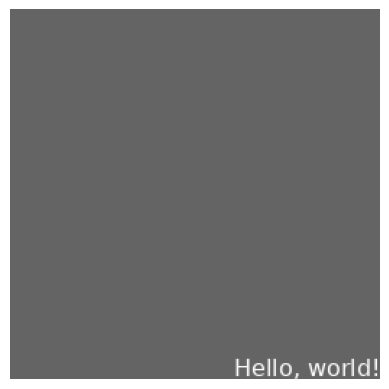

In [13]:
# Fake image
img = np.ones((256, 256, 3), dtype=np.uint8) * 100

# Add text safely
img_with_text = draw_text_on_image(img, "Hello, world!", position=(200, 240), font_size=16)

# View it with matplotlib
import matplotlib.pyplot as plt
plt.imshow(img_with_text)
plt.axis('off')
plt.show()
